# POC — `fedwater_lab` end to end

A thin driver. Everything substantive lives in `fedwater_lab/`; this notebook picks a
world, runs a cell, checks the artifact contract, scores, and plots. The two notebooks it
replaces (`aer_federated_sandbox_plot`, `PP_01__preprocessing_x_placement_latent`) each had
their own copy of the trainer, the window builder, the metrics and the store; those are now
single definitions, so their numbers are comparable for the first time.

| module | owns |
|---|---|
| `bridge` | the only import seam to `fedwater` — nothing upstream is re-implemented |
| `worlds` | world dir → params merge, ground truth (derived **twice** and asserted), phases from the drift schedule |
| `specs` | the experiment axes as data; `CellSpec.key()` is the run identity |
| `data` | placement → transform → windows → scaling (incl. the new pooled `shared`) |
| `train` | one `SnapshotFPLTrainer`: month-stratified snapshots, `stage=pre|post`, update Gram |
| `store` | two layers — immutable `runs/`, appendable `scores/` |
| `metrics` | one definition of every latent / probe / drift metric |
| `cluster` | similarity + partition, **one `(scope, round, phase)` slice at a time** |
| `figures` / `widgets` | pure `df → Axes`, plus thin ipywidgets wiring |

**Not in scope for this pass:** new similarity channels, hydraulic decoupling, gradual/
progress-based scoring, cross-world pooling. Drift metrics are computed and stored but never
rank or gate anything.

## 0. Setup

In [1]:
import sys, pathlib
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

# <repo>/src must be importable: the lab borrows fedwater's own code.
REPO = next((p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
             if (p / "src" / "fedwater").is_dir()), None)
assert REPO is not None, "run this from inside the fedwater repo"

HC_DIR = 'c:\\Users\\arthu\\USPy\\10_Mestrado\\fedWater\\notebooks\\0_prospection'

for p in (REPO / "src", HC_DIR):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))


from fedwater_lab import load_world, Store, POC, expand
from fedwater_lab.runner import run_cell, run_grid
from fedwater_lab import data as D, metrics as M, cluster as C, figures as F

pd.set_option("display.width", 200)
print(f"repo {REPO}")

repo c:\Users\arthu\USPy\10_Mestrado\fedWater


## 1. World

Entry point is a **path** to the world directory (the one holding `manifest.json` and
`clone/`). Params are the clone's `conf/base/parameters.yml` deep-merged with
`manifest.effective` — the manifest wins for anything the simulator actually ran with, and
supplies nothing for `fl`, which is why both sources are needed.

Read the summary carefully: **the label-clean stretches are short.** With `warmup_months=6`,
node switches spanning months 6→23 and a 42-day ramp per switch, `init` is months 0–5 and
`final` is 25–29 — 11 of 30 months. Everything else is transition and belongs to neither
phase. That is the real constraint on the init-state question, not the choice of method.

In [2]:
WORLD_DIR = REPO / "data" / "09_experiments" / "worlds" / "b3e18c6b0a3e"
world = load_world(WORLD_DIR)
store = Store(REPO / "notebooks" / "prospection" / "lab_sandbox")

print(world.summary().to_string())
print(f"\nground truth, derived two ways (asserted equal at load):")
for src, mapping in world.regime_sources.items():
    print(f"  {src:<26} {mapping}")
print(f"\nstore {store}")

sim_hash                                  b3e18c6b0a3e
tag               District_E__LR_LR_LR_LI_LI__baseline
n_months                                            40
resolution_h                                         1
steps_day                                           24
clients                                              5
drift_district                              District_E
warmup_months                                        8
first_switch                                         8
last_switch                                         39
ramp_days                                         42.0
init_months                                       0..7
final_months                                    40..39
regime_init                             LR_LR_LR_LI_LI
regime_final                            LR_LR_LR_LI_LR

ground truth, derived two ways (asserted equal at load):
  income_landuse_mapping     {'District_A': 'LR', 'District_B': 'LR', 'District_C': 'LR', 'District_D': 'LI', 'Distri

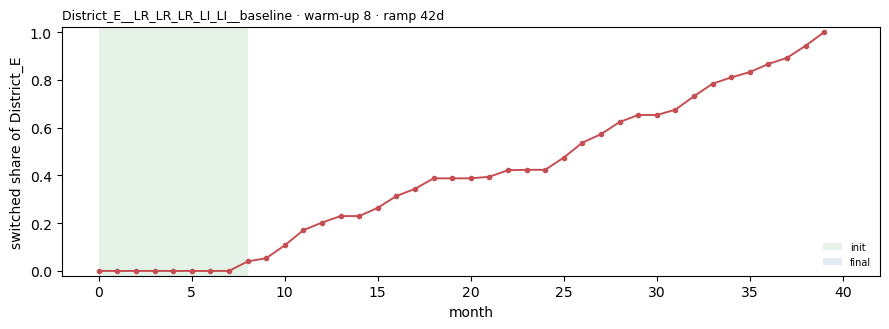

In [3]:
fig, ax = plt.subplots(figsize=(9, 3.4))
F.plot_drift_progress(ax, world)
fig.tight_layout()

## 2. The data path

Every placement is built the same way from `pressures`/`flows` — `manual` included, read from
`manifest.effective.sensors`. The shipped `07_model_output/clients/*.csv` are deliberately
**not** used: they carry `observed` (noisy) values, so mixing them with rebuilt placements
would confound the placement axis with a noise axis. The check below shows exactly that —
columns identical, values differing by roughly the noise sigma.

In [4]:
tgt_district = world.drift_district

frames = D.client_frames(world, "manual")
csv = pd.read_csv(world.clients_dir / f"{tgt_district}.csv")
csv_sensor = csv.columns[-1]

diff = np.abs(csv[csv_sensor].to_numpy() - frames[f"{tgt_district}"][csv_sensor].to_numpy()).mean()

print(f"channels per client : {D.assert_equal_channels(frames)}")
print(f"columns match CSV   : {list(csv.columns) == list(frames[f'{tgt_district}'].columns)}")
print(f"clean vs observed   : {diff:.4f} mean abs  "
      f"(flow_sigma={world.params['noise']['flow_sigma']}) -> the CSVs are noisy")
print(f"sensor_hash(manual) : {D.sensor_hash(D.resolve_placement(world, 'manual'))}")

rows = []
for t in ["none", "slog", "diff", "deseason_own", "deseason_shared"]:
    v = D.apply_transform(frames, t, world.steps_day)[f"{tgt_district}"][csv_sensor].to_numpy()
    rows.append({"transform": t, "mean": v.mean(), "sd": v.std()})
pd.DataFrame(rows).round(4)

channels per client : 5
columns match CSV   : True
clean vs observed   : 0.1995 mean abs  (flow_sigma=0.25) -> the CSVs are noisy
sensor_hash(manual) : e411ade2


,transform,mean,sd
0,none,3.3299,2.2893
1,slog,1.2698,0.7111
2,diff,-0.0001,1.0313
3,deseason_own,-0.0000,0.1649
4,deseason_shared,3.2265,0.4608


### 2a. The scaling axis, with its sanity check

`preprocess_clients` always fits a per-client MinMax on the reference months, which pins
every client to exactly the feature range and therefore **deletes cross-client level**. The
new `shared` mode inverts that map with `fl_scalers` and refits one MinMax on the *pooled*
reference windows, so level survives into the model input.

`identical_bounds` is the check that says which of the two actually happened — `True` means
per-client, and it is the reason an AER-sandbox-style `scaling: "shared"` override on
`fl.preprocessing` was inert.

Note `reference_months` resolves to the world's own `warmup_months`, and is asserted not to
reach past the first node switch — a scaler fitted past it would have seen the drift it is
supposed to make visible.

reference_months = 4 (warm-up 4, first switch 4)


,scaling,identical_bounds,A,B,C,D,E
0,minmax_ref,False,-1.00..+1.00,-1.00..+1.00,-1.00..+1.00,-1.00..+1.00,-1.00..+1.29
1,shared,False,-0.92..+1.00,-0.89..+1.00,-1.00..+0.94,-1.00..+1.00,-1.00..+0.92
2,none,False,+0.01..+47.46,-2.99..+103.61,-44.87..+47.31,-7.91..+84.20,+2.05..+47.26
3,zscore,False,-1.46..+3.32,-2.25..+1.76,-2.90..+2.42,-1.81..+1.80,-1.81..+3.04


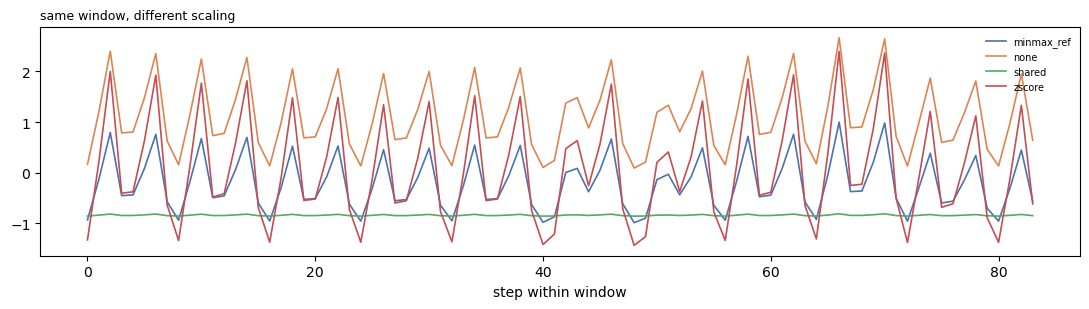

In [5]:
spec = POC
rows, variants = [], {}
for mode in ["minmax_ref", "shared", "none", "zscore"]:
    fw, sc, fl = D.build_windows(world, spec.with_(scaling=mode), cache=D.CACHE)
    rr = D.ref_range_per_client(fw, fl["preprocessing"]["reference_months"])
    variants[mode] = fw
    rows.append({"scaling": mode, "identical_bounds": rr.attrs["identical_bounds"],
                 **{f"{r['client'][-1]}": f"{r['min']:+.2f}..{r['max']:+.2f}"
                    for _, r in rr.iterrows()}})
print(f"reference_months = {fl['preprocessing']['reference_months']} "
      f"(warm-up {world.warmup_months}, first switch {world.first_switch})")
display(pd.DataFrame(rows))

fig, ax = plt.subplots(figsize=(11, 3.2))
F.plot_scaling_compare(ax, variants, index=0, channel=2, client="District_A")
fig.tight_layout()

## 3. Train one cell

`run_cell` is the single entry point: a **cache read** when the key exists, a train otherwise.
The key is a hash over the normalized spec, the world hash and the resolved sensor set, so
re-running a grid costs nothing and a placement rule that silently changes its sensors shows
up as a new key rather than a corrupted cache hit.

In [6]:
res = run_cell(world, spec, store=store, verbose=True)
res.setdefault("snapshots", res.get("latents_by_round"))

print(f"run_key {res['run_key']}  cache_hit={res['cache_hit']}  {res.get('seconds')}s")
for k in ["prototype_history", "global_prototype_history", "latents_by_round",
          "latent_trajectories", "prototypes", "update_gram", "drift_signals"]:
    v = res.get(k) if res.get(k) is not None else res.get("snapshots")
    print(f"  {k:<26} {None if v is None else v.shape}")

  round   0  loss 0.68186  online 5
  round   1  loss 1.34215  online 5
  round   2  loss 1.26404  online 5
  round   3  loss 1.21916  online 5
  round   4  loss 1.18608  online 5
run_key 70ecae3398b5  cache_hit=False  18.1s
  prototype_history          (750, 63)
  global_prototype_history   (176, 63)
  latents_by_round           (10500, 69)
  latent_trajectories        (2390, 67)
  prototypes                 (1526, 65)
  update_gram                (75, 6)
  drift_signals              (150, 4)


### 3a. The artifact contract

The check that matters is `prototypes == eval-mode mean latent`: `extract_prototypes` on a
client's final model must reproduce the per-month mean of `latent_trajectories`, i.e.
prototypes and the latent table are the same object computed the same way. The
trainer-dependent rows only appear on a fresh train (a cache hit has no trainer), which is
correct — pass `overwrite=True` to exercise them.

In [7]:
checks = M.check_run(res, world)
assert checks["passed"].all(), checks[~checks["passed"]]
checks

,check,value,passed
0,latent_dim,60,True
1,prototype_dim,60,True
2,latent_rows == windows,2390,True
3,latents_finite,True,True
4,prototypes_finite,True,True
5,proto_rows,750,True
6,global_proto_rounds,5,True
7,clients_synced_after_fedavg,True,True
8,prototypes == eval-mode mean latent,0.0,True
9,snapshots have pre and post,"[post, pre]",True


### 3b. What the refactor bought: the prototype family + stratified snapshots

Three scopes of the same object, plus a fourth computed over *all* windows rather than the
snapshot subset:

| scope | what | source |
|---|---|---|
| `local` | per-client per-month mean latent, **pre-FedAvg** | `prototype_history` |
| `global` | FINCH cluster centroids per month, server side | `global_prototype_history` |
| `post_fedavg` | same, under the **global** weights | snapshots with `stage=post` |
| `post_fedavg_full` | ditto, all windows, final round | `latent_trajectories` |

`post_fedavg` previously existed only at the final round. With the post-FedAvg hook it exists
at every snapshot round, so the local/global asymmetry is measurable over the round axis
rather than once at the end.

Snapshots are month-stratified: the notebooks sampled uniformly over the timeline, which gave
the six label-clean init months roughly a fifth of the points.

In [8]:
snaps, protos = res["snapshots"], res["prototypes"]
display(protos.groupby("scope").agg(rows=("month", "size"), rounds=("round", "nunique")))
print(f"fedavg_gap (mean cosine distance local -> post_fedavg): "
      f"{__import__('fedwater_lab.train', fromlist=['x']).fedavg_gap(protos):.4f}\n")

display(snaps.groupby(["round", "stage"]).size().unstack("stage"))
print("snapshot rows per month (stratification check, round 0 / stage pre):")
display(snaps[(snaps["round"] == 0) & (snaps["stage"] == "pre")]
        .groupby(["district", "month"]).size().unstack("month").iloc[:, :10])

,rows,rounds
scope,,
global,176,5
local,750,5
post_fedavg,450,3
post_fedavg_full,150,1


fedavg_gap (mean cosine distance local -> post_fedavg): 0.0096



stage,post,pre
round,,
-1,NaN,1500.0
0,1500.0,1500.0
2,1500.0,1500.0
4,1500.0,1500.0


snapshot rows per month (stratification check, round 0 / stage pre):


month,0,1,2,3,4,5,6,7,8,9
district,,,,,,,,,,
District_A,10,10,10,10,10,10,10,10,10,10
District_B,10,10,10,10,10,10,10,10,10,10
District_C,10,10,10,10,10,10,10,10,10,10
District_D,10,10,10,10,10,10,10,10,10,10
District_E,10,10,10,10,10,10,10,10,10,10


## 4. Score

Scores live in a separate store layer keyed back to `run_key`, so a new method is scored over
the whole existing grid with no GPU. Nothing here ranks cells on drift.

`round = 9999` is the final model over all windows, which is not a snapshot round. Note
`probe_district` sits near 1.0 already at round `-1` (the untrained control): a random
projection separates clients, which is why the controlled probes exist.

In [9]:
lm = M.score_run(res, world)
store.save_scores("latent_metrics", lm, keys=("world_hash", "run_key", "round", "stage"))
lm[["round", "stage", "n", "sil_district", "sil_month", "probe_district",
    "probe_month", "chance_month", "pca90", "eff_dim"]].round(3)

,round,stage,n,sil_district,sil_month,probe_district,probe_month,chance_month,pca90,eff_dim
0,-1,pre,1500,0.054,-0.172,1.0,0.102,0.033,6,3.644
1,0,pre,1500,0.138,-0.150,1.0,0.107,0.033,7,3.940
2,2,pre,1500,0.037,-0.142,1.0,0.120,0.033,7,4.945
3,4,pre,1500,0.028,-0.130,1.0,0.118,0.033,7,4.355
4,9999,final_all_windows,2390,0.030,-0.175,1.0,0.109,0.033,6,3.976


In [10]:
ctrl = M.probe_controlled(snaps[(snaps["round"] == snaps["round"].max())
                                & (snaps["stage"] == "pre")], world, phase="init")
pd.Series(ctrl).round(4).to_frame("value")

,value
n,1500.0000
month_within_district,0.2600
chance_month_within,0.0333
regime_lodo,0.4000
regime_lodo_p,0.4400
regime_lodo_null,0.3760
regime_lodo_folds,5.0000


### 4a. Similarity — one `(scope, round, phase)` slice at a time

Enforced by assertion, not convention. In `prototype_history` the round explains the large
majority of the variance, because all clients' prototypes migrate together as training
proceeds; a matrix computed over the stacked table measures training progress, not client
identity. So round is a **loop axis you watch**.

Read `gap_lift` (real minus shuffle-null mean), not the raw gap, and mind `p_floor`: with 5
clients the exhaustive label-shuffle null has 10 distinct assignments for a 3–2 split (floor
0.10) and 5 for a 4–1 split (floor 0.20). A 4–1 world can never be individually significant.
`sd_offdiag` flags degeneracy: after the deconfounding the mean off-diagonal cosine is pinned
near `-1/(N-1)`, so spread is the readable quantity, never the mean.

In [11]:
sim, clu = C.score_run(res, world,
                       methods=("proto_cos", "proto_cos_dc", "drift_sig", "update_cos"),
                       scopes=("local", "post_fedavg"))
store.save_scores("similarity", sim)
store.save_scores("clusters", clu)

(clu.drop_duplicates(["scope", "round", "phase", "method"])
    [["scope", "round", "phase", "method", "regime_gap", "gap_lift", "gap_p",
      "p_floor", "ari", "sd_offdiag"]]
    .sort_values(["phase", "method", "round"]).round(3).to_string(index=False))

'      scope  round phase       method  regime_gap  gap_lift  gap_p  p_floor    ari  sd_offdiag\n      local      0 final    drift_sig      -0.001    -0.001    1.0      0.1 -0.250       0.002\npost_fedavg      0 final    drift_sig      -0.001    -0.001    1.0      0.1 -0.250       0.002\n      local      1 final    drift_sig      -0.001    -0.001    1.0      0.1 -0.250       0.002\n      local      2 final    drift_sig      -0.001    -0.001    1.0      0.1 -0.250       0.002\npost_fedavg      2 final    drift_sig      -0.001    -0.001    1.0      0.1 -0.250       0.002\n      local      3 final    drift_sig      -0.001    -0.001    1.0      0.1 -0.250       0.002\n      local      4 final    drift_sig      -0.001    -0.001    1.0      0.1 -0.250       0.002\npost_fedavg      4 final    drift_sig      -0.001    -0.001    1.0      0.1 -0.250       0.002\n      local      0 final    proto_cos       0.154     0.154    0.1      0.1  0.000       0.210\npost_fedavg      0 final    proto_cos  

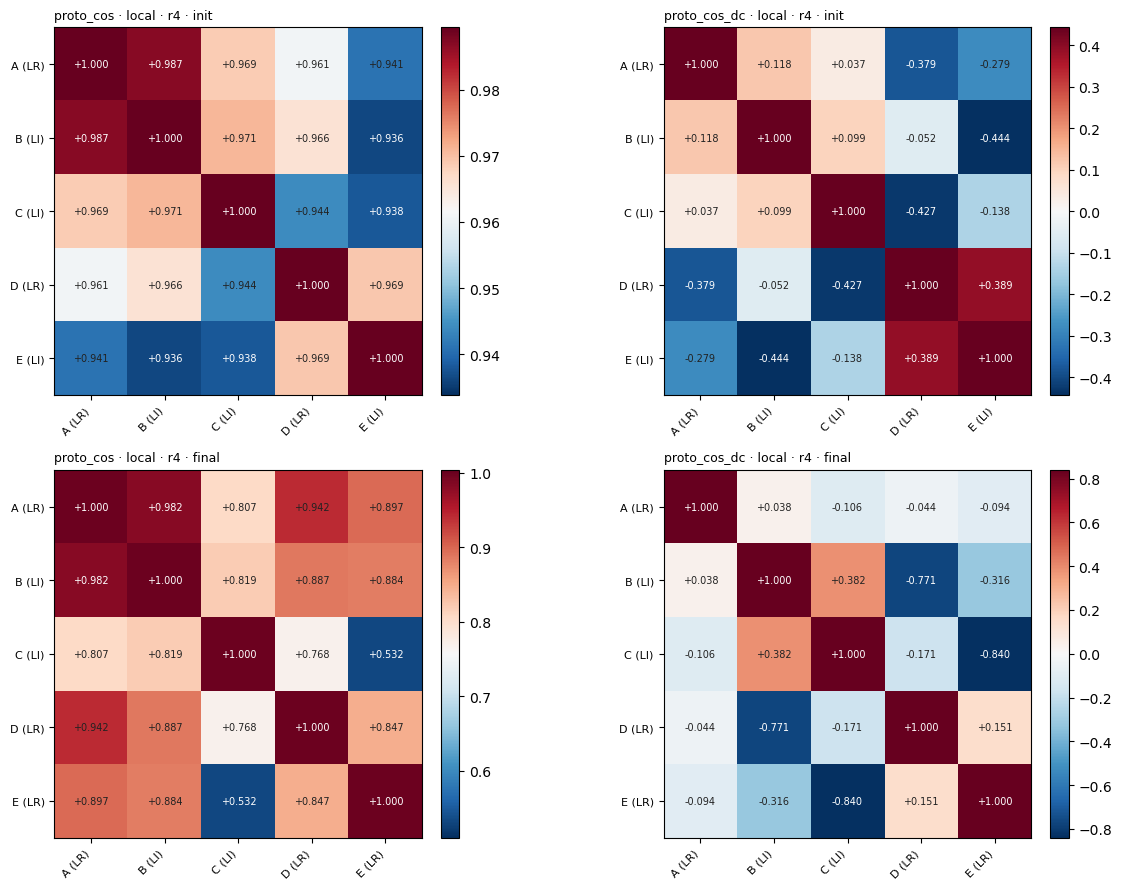

In [12]:
r_last = int(protos[protos["scope"] == "local"]["round"].max())
fig, ax = plt.subplots(2, 2, figsize=(13, 9))
for a, (method, phase) in zip(ax.ravel(),
                              [("proto_cos", "init"), ("proto_cos_dc", "init"),
                               ("proto_cos", "final"), ("proto_cos_dc", "final")]):
    S = C.similarity(protos, world, method, "local", r_last, phase,
                     drift_signals=res["drift_signals"], update_gram=res["update_gram"])
    F.plot_similarity(a, S, world.regimes(phase=phase),
                      title=f"{method} · local · r{r_last} · {phase}")
fig.tight_layout()

## 5. Latent space and prototypes

Prototypes are **means** of latents, so they live in the same space and must be read through
the *same* projection as the windows they summarise. `fit_on="windows"` reads them into the
window cloud — but being means they collapse near its centroid and their mutual structure,
which is what the clustering question is about, becomes unreadable. `fit_on="prototypes"`
anchors the same kind of linear map on them and sends the windows through it. Both are one
map applied to both sets.

Marker key: `o` local (pre-FedAvg), `s` post-FedAvg, `P` post-FedAvg over all windows,
`D` global FINCH cluster. `trajectory` joins each client's prototypes in month order.

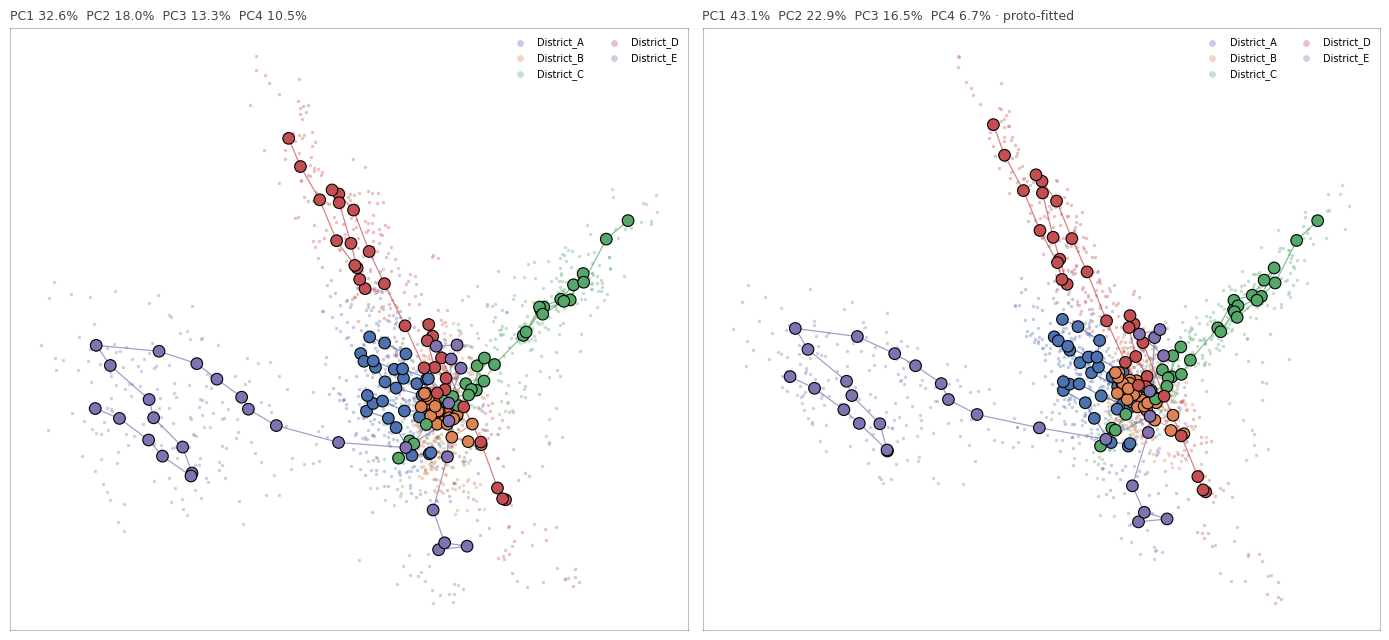

In [13]:
d = (snaps[(snaps["round"] == r_last) & (snaps["stage"] == "pre")]
     .reset_index(drop=True))
pr = protos[(protos["scope"] == "local") & (protos["round"] == r_last)].reset_index(drop=True)
Zp, Zq = d[F.fcols(d)].to_numpy(), pr[F.fcols(pr)].to_numpy()

fig, ax = plt.subplots(1, 2, figsize=(14, 6.5))
for a, fit in zip(ax, ["windows", "prototypes"]):
    Ep, Eq, sub = F.project(Zp, Zq, "PCA", 0, fit)
    F.plot_latent(a, d, Ep, pr, Eq, colour_by="district", subtitle=sub, trajectory=True)
    a.legend(fontsize=7, frameon=False, markerscale=2, ncol=2)
fig.tight_layout()

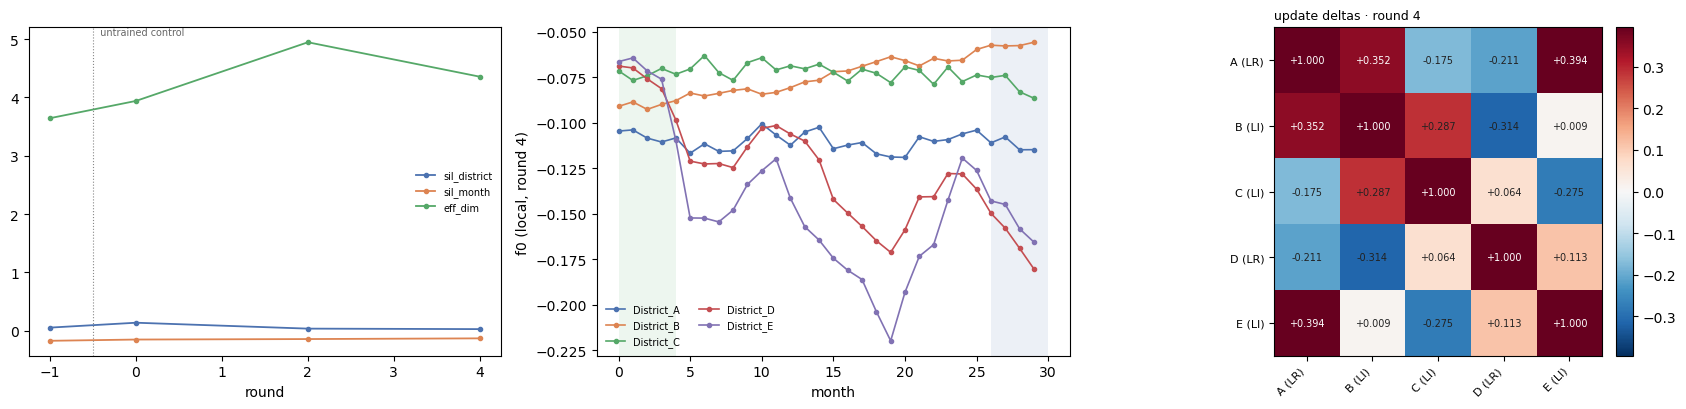

In [14]:
fig, ax = plt.subplots(1, 3, figsize=(17, 4.2))
F.plot_metrics_by_round(ax[0], M.metrics_by_round(snaps, stage="pre"))
F.plot_prototype_trajectory(ax[1], protos, world, "local", r_last, component=0)
F.plot_update_gram(ax[2], res["update_gram"], r_last, world.regimes(phase="init"))
fig.tight_layout()

## 6. Interactive browsers

`latent_browser` reads persisted tables only, so what you see is what the run saved.
`preprocessing_browser` is the one place that must rebuild windows on a control change, so it
takes an explicit **bounded** cache and only rebuilds when you press *Materialize* — the
notebooks rebuilt on every slider event against an unbounded module-level dict.

In [15]:
from fedwater_lab import widgets as WGT
_ = WGT.latent_browser(world, res)

In [ ]:
_ = WGT.preprocessing_browser(world, spec, cache=D.CACHE)

## 7. A grid, and the retention policy

`expand` takes a base spec and dotted axes. Re-running is a disk-cache read.

`disk_usage` is the input to the weight-retention decision, and it settles it: the dominant
artifact is `latents_by_round`, not `fed_model`. So the dial that matters is snapshot
resolution (`snapshot_rounds="sparse"` keeps `{-1, 0, mid, final}`), while
`prototype_history` stays at every round because that is what every similarity channel
consumes. Final-round weights are cheap and kept; per-round weights are never needed, because
the two channels that would want them read the `update_gram` computed at train time.

In [17]:
GRID = expand(spec, {"transform": ["none", "diff"],
                     "scaling": ["minmax_ref", "shared"]})
print(f"{len(GRID)} cells")
ran, fails = run_grid(world, GRID, store=store)
if len(fails):
    display(fails)
display(store.index(world.sim_hash)[["run_key", "transform", "scaling", "rounds",
                                     "n_windows", "seconds"]])
store.disk_usage(world.sim_hash)

4 cells
[1/4] manual-fp__none__minmax_ref__a3w84s12__u30r5s0                 cached
[2/4] manual-fp__none__shared__a3w84s12__u30r5s0                     10.1s
[3/4] manual-fp__diff__minmax_ref__a3w84s12__u30r5s0                 15.2s
[4/4] manual-fp__diff__shared__a3w84s12__u30r5s0                     17.3s


,run_key,transform,scaling,rounds,n_windows,seconds
0,70ecae3398b5,none,minmax_ref,5,2390,18.1
1,a6f9094d7db3,none,shared,5,2390,10.1
2,627f7eecb038,diff,minmax_ref,5,2390,15.2
3,fe2ae0a50054,diff,shared,5,2390,17.3


,count,mean,MB
artifact,,,
latents_by_round,4,3677086.00,14.03
fed_model,4,939142.00,3.58
latent_trajectories,4,832878.00,3.18
prototypes,4,526797.00,2.01
prototype_history,4,273439.00,1.04
global_prototype_history,4,85804.25,0.33
update_gram,4,5512.50,0.02
drift_signals,4,5303.50,0.02
fl,4,1834.00,0.01


In [18]:
# Re-score the whole grid from disk -- no retraining, no GPU.
rows = []
for r in store.index(world.sim_hash).itertuples():
    saved = store.load_run(r.world_hash, r.run_key)
    saved["snapshots"] = saved.get("latents_by_round")
    _, clu_i = C.score_run(saved, world, run_key=r.run_key,
                           methods=("proto_cos", "proto_cos_dc"), scopes=("local",))
    if len(clu_i):
        rows.append(clu_i.assign(transform=r.transform, scaling=r.scaling))
allclu = pd.concat(rows, ignore_index=True)
store.save_scores("clusters", allclu)

(allclu[allclu["round"] == allclu["round"].max()]
 .drop_duplicates(["transform", "scaling", "phase", "method"])
 .pivot_table(index=["transform", "scaling"], columns=["phase", "method"],
              values="gap_lift")
 .round(3))

phase                    final                   init             
method               proto_cos proto_cos_dc proto_cos proto_cos_dc
transform scaling                                                 
diff      minmax_ref     0.023       -0.083    -0.003       -0.046
          shared         0.012        0.310     0.004        0.014
none      minmax_ref     0.066        0.460    -0.011       -0.180
          shared         0.021       -0.059     0.060       -0.265

## What is deliberately left open

* **Power.** 5 clients and 2 tokens put the exhaustive-null p-floor at 0.10 (3–2) or 0.20
  (4–1). No amount of refactoring creates statistics; more worlds, 3-token maps, or a finer
  scoring unit do.
* **Label-clean months.** 6 init and 5 final in this world. Longer warm-up and post-drift
  stretches are the prerequisite for the init-state question, not an optimisation.
* **New channels.** `cluster.METHODS` is a registry; the ported channels are in it and the
  slice API is shaped to accept more (decoder reconstruction, second-moment/CKA,
  distributional distances, transfer error). None were added in this pass.
* **Common-mode contamination.** Visible above as raw `proto_cos` near 0.97 for every pair.
  Hydraulic coupling, pinned for later.
* **`variance` placement.** Excluded from `PLACEMENTS`: it ranks candidates on the world's
  own residual statistics, so it is deterministic within a world but data-dependent across
  worlds. `sensor_hash` in the run key is what will make that safe to add.